In [1]:
import numpy as np
import matplotlib.pyplot as plt

from graspologic.match import graph_match
import graspologic.match.wrappers as wrappers

from utils.Graphs import (
    gen_ER_graphs,
    gen_SBM_graphs,
    gen_correlated_powerlaw_graphs,
)
from utils.SeedingMethods import (
    random_seeds,
    highest_degree_seeds,
    betweenness_seeds,
)


# ============================================================
# 1. TEMPORARILY MODIFY SGM TO SAVE Q^(i), P^(i), AND alpha_i
#    This changes only the current notebook session.
# ============================================================

last_solver = None


def solve_with_history(self, rng=None):
    global last_solver
    last_solver = self

    rng = np.random.default_rng(rng)

    self.n_iter_ = 0
    self.P_history_ = []
    self.Q_history_ = []
    self.alpha_history_ = []

    if self.n_seeds == self.n:
        P = np.empty((0, 0))
        self.converged_ = True
    else:
        # Initial doubly stochastic matrix P^(0)
        P = self.initialize(rng)
        self.P_history_.append(P.copy())

        self.compute_constant_terms()

        for n_iter in range(self.max_iter):
            self.n_iter_ = n_iter + 1

            gradient = self.compute_gradient(P)

            # Hungarian solution Q^(i)
            Q = self.compute_step_direction(gradient, rng)

            # graspologic uses:
            # P^(i+1) = alpha_i P^(i) + (1-alpha_i) Q^(i)
            alpha = self.compute_step_size(P, Q)

            self.Q_history_.append(Q.copy())
            self.alpha_history_.append(float(alpha))

            P_new = alpha * P + (1 - alpha) * Q
            self.P_history_.append(P_new.copy())

            if self.check_converged(P, P_new):
                self.converged_ = True
                P = P_new
                break

            P = P_new

    self.finalize(P, rng)


wrappers._GraphMatchSolver.solve = solve_with_history


# ============================================================
# 2. RUN ONE COLLECTION OF TRIALS
# ============================================================

def run_h0_experiment(
    graph_gen_func,
    seeding_func,
    n_seeds,
    n_trials=25,
    graph_kwargs=None,
    verbose=True,
):
    """
    For each trial, record:

    H0:
        Match ratio of the first Hungarian direction Q^(0)
        on the unseeded vertices.

    final_unseeded:
        Final SGM match ratio on the unseeded vertices.

    final_all:
        Final SGM match ratio on all vertices, including seeds.

    alpha0:
        First line-search coefficient in graspologic's convention:
        P^(1) = alpha0 P^(0) + (1-alpha0) Q^(0).
    """
    if graph_kwargs is None:
        graph_kwargs = {}

    records = []

    for trial in range(n_trials):
        # stored_perm is the indexing used to reorder G2:
        # G2_shuffled = G2[stored_perm][:, stored_perm]
        G1, G2_shuffled, stored_perm = graph_gen_func(**graph_kwargs)

        # Correct map from original G1 labels to shuffled G2 labels
        true_perm = np.argsort(stored_perm)

        # Give the seeding rule the actual correct correspondence
        seeds_G1, seeds_G2 = seeding_func(
            G1,
            G2_shuffled,
            n_seeds,
            true_perm,
        )

        # Safety check: supplied seeds must be correct
        if not np.array_equal(true_perm[seeds_G1], seeds_G2):
            raise ValueError(
                "The seeding function returned pairs inconsistent "
                "with the true G1-to-G2 permutation."
            )

        partial_match = np.column_stack((seeds_G1, seeds_G2))

        result = graph_match(
            G1,
            G2_shuffled,
            partial_match=partial_match,
        )

        if last_solver is None or len(last_solver.Q_history_) == 0:
            raise RuntimeError("The SGM history was not recorded.")

        # ----------------------------------------------------
        # First-direction match ratio H0
        # ----------------------------------------------------
        Q0 = last_solver.Q_history_[0]

        # Rows and columns of Q0 correspond to these original labels
        rows_A = last_solver.perm_A[last_solver.n_seeds:]
        cols_B = last_solver.perm_B[last_solver.n_seeds:]

        predicted_column_positions = np.argmax(Q0, axis=1)
        predicted_B_from_Q0 = cols_B[predicted_column_positions]
        true_B_for_rows = true_perm[rows_A]

        H0 = np.mean(predicted_B_from_Q0 == true_B_for_rows)

        # ----------------------------------------------------
        # Final SGM permutation
        # ----------------------------------------------------
        predicted_perm = np.empty_like(true_perm)
        predicted_perm[result.indices_A] = result.indices_B

        all_vertices = np.arange(len(true_perm))
        unseeded_A = np.setdiff1d(
            all_vertices,
            seeds_G1,
            assume_unique=False,
        )

        final_unseeded = np.mean(
            predicted_perm[unseeded_A] == true_perm[unseeded_A]
        )

        final_all = np.mean(predicted_perm == true_perm)

        alpha0 = last_solver.alpha_history_[0]
        step_toward_Q0 = 1.0 - alpha0

        record = {
            "trial": trial + 1,
            "H0": H0,
            "final_unseeded": final_unseeded,
            "final_all": final_all,
            "alpha0": alpha0,
            "step_toward_Q0": step_toward_Q0,
            "n_iter": last_solver.n_iter_,
        }
        records.append(record)

        if verbose:
            print(
                f"trial {trial + 1:>3}: "
                f"H0={H0:.4f}, "
                f"final_unseeded={final_unseeded:.4f}, "
                f"final_all={final_all:.4f}, "
                f"step_to_Q0={step_toward_Q0:.4f}"
            )

    H0_values = np.array([r["H0"] for r in records])
    final_unseeded_values = np.array(
        [r["final_unseeded"] for r in records]
    )
    final_all_values = np.array([r["final_all"] for r in records])
    alpha0_values = np.array([r["alpha0"] for r in records])

    # Correlation is undefined if either variable is constant
    if np.std(H0_values) == 0 or np.std(final_unseeded_values) == 0:
        correlation = np.nan
    else:
        correlation = np.corrcoef(
            H0_values,
            final_unseeded_values,
        )[0, 1]

    summary = {
        "mean_H0": H0_values.mean(),
        "mean_final_unseeded": final_unseeded_values.mean(),
        "mean_final_all": final_all_values.mean(),
        "mean_alpha0": alpha0_values.mean(),
        "correlation_H0_final_unseeded": correlation,
    }

    print("\nSummary")
    print("-------")
    print(f"Mean H0:                    {summary['mean_H0']:.4f}")
    print(
        "Mean final unseeded ratio: "
        f"{summary['mean_final_unseeded']:.4f}"
    )
    print(
        "Mean final all-vertex ratio: "
        f"{summary['mean_final_all']:.4f}"
    )
    print(f"Mean alpha0:                {summary['mean_alpha0']:.4f}")
    print(
        "Correlation(H0, final unseeded): "
        f"{summary['correlation_H0_final_unseeded']:.4f}"
    )

    return records, summary


# ============================================================
# 3. OPTIONAL SCATTERPLOT
# ============================================================

def plot_h0_vs_final(records, title="H0 versus final SGM accuracy"):
    x = np.array([r["H0"] for r in records])
    y = np.array([r["final_unseeded"] for r in records])

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y)
    plt.xlabel("First-direction match ratio H0")
    plt.ylabel("Final unseeded match ratio")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


print("Experiment code is ready.")

Experiment code is ready.


trial   1: H0=0.1000, final_unseeded=0.0828, final_all=0.1133, step_to_Q0=1.0000
trial   2: H0=0.1345, final_unseeded=1.0000, final_all=1.0000, step_to_Q0=1.0000
trial   3: H0=0.1172, final_unseeded=1.0000, final_all=1.0000, step_to_Q0=1.0000
trial   4: H0=0.0724, final_unseeded=0.0759, final_all=0.1067, step_to_Q0=1.0000
trial   5: H0=0.0897, final_unseeded=0.1069, final_all=0.1367, step_to_Q0=1.0000
trial   6: H0=0.1000, final_unseeded=0.0931, final_all=0.1233, step_to_Q0=1.0000
trial   7: H0=0.0897, final_unseeded=0.2207, final_all=0.2467, step_to_Q0=1.0000
trial   8: H0=0.1207, final_unseeded=1.0000, final_all=1.0000, step_to_Q0=1.0000
trial   9: H0=0.1103, final_unseeded=1.0000, final_all=1.0000, step_to_Q0=1.0000
trial  10: H0=0.0966, final_unseeded=0.1310, final_all=0.1600, step_to_Q0=1.0000
trial  11: H0=0.1379, final_unseeded=1.0000, final_all=1.0000, step_to_Q0=1.0000
trial  12: H0=0.0655, final_unseeded=0.0655, final_all=0.0967, step_to_Q0=1.0000
trial  13: H0=0.1276, final_

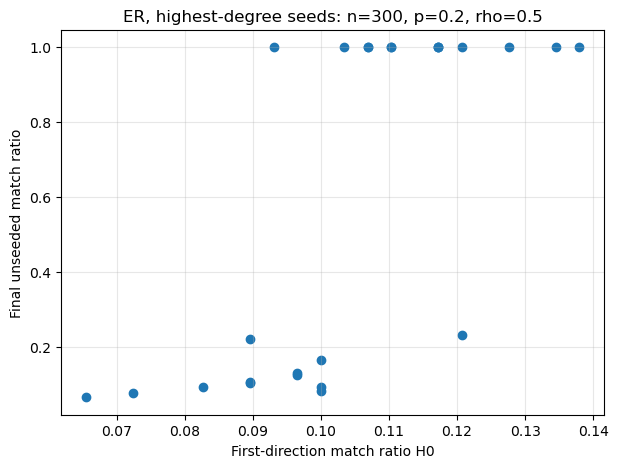

In [11]:
records, summary = run_h0_experiment(
    graph_gen_func=gen_ER_graphs,
    seeding_func=highest_degree_seeds,
    n_seeds=10,
    n_trials=25,
    graph_kwargs={
        "n": 300,
        "p": 0.2,
        "rho": 0.5,
    },
)

plot_h0_vs_final(
    records,
    title="ER, highest-degree seeds: n=300, p=0.2, rho=0.5",
)